Copyright (c) 2025 Mitsuru Ohno  
Use of this source code is governed by a BSD-3-style  
license that can be found in the LICENSE file.  

## 当ノートブックのワークフロー  
複数のデータフレームを横断的に処理する事例。3成分で相互平衡になっている。  
1. 未知の速度定数を含む、csvに書き込んだ反応式を読み込む。  
2. 化学種の濃度の経時変化の実験データを読み込む。初期濃度を変化させた複数の条件での実験結果を用い、全体を最適化できる速度定数を求めることを目標とする。  
2. 化学種ごとの微分型の反応速度式を作成する。速度定数が未知の素反応にはシンボリックな変数が割り振られる、  
3. 作成した微分方程式を、数値解析可能な形式にする  
4.  scipy.optimize.minimizeを使い、化学種ごとの濃度の経時変化が、実験値と近づくように、未知の速度定数を求める。本ノートブックでは、0に近い速度定数を持つ素反応も含まれることを想定し、速度定数を対数処理してから最適化するモード（def run_fitの引数をuse_log_fit=Trueにする）を用いた。  
5. 経時変化を図示する  

残念ながら、df2の結果を再現できていない。複数のデータフレームを横断的に処理する実行例として掲載する。  

## 反応式を記載したcsvファイルを指定する  

In [1]:
file_path_rxn = './sample_data/ref5/sample_rxn_ref5.csv'  # CSVファイルのパスを指定

## 反応速度式をscipy.integrate.solve_ivpで処理できる連立微分方程式にする  

In [2]:
import numpy as np
import pandas as pd

from rxnfit import RxnODEbuild, SolverConfig, RxnODEsolver
from rxnfit.expdata_reader import expdata_read
from rxnfit.expdata_fit_sci import ExpDataFitSci


# 反応速度式の作成

In [3]:
builded_rxnode = RxnODEbuild(file_path_rxn)

In [4]:
builded_rxnode.get_ode_info(debug_info=True)

number of species: 3
unique species: ['oXy', 'pXy', 'mXy']
rate constant: {'k1': k1, 'k2': k2, 'k3': k3, 'k4': k4, 'k5': k5, 'k6': k6}

=== debug info ===
Successfully created function for oXy with args: ['t', 'oXy', 'pXy', 'mXy']
Successfully created function for pXy with args: ['t', 'oXy', 'pXy', 'mXy']
Successfully created function for mXy with args: ['t', 'oXy', 'pXy', 'mXy']
order of args: ['t', 'oXy', 'pXy', 'mXy']
system of ODE: {'oXy': '-1/1*k1*oXy(t)+1/1*k2*pXy(t)-1/1*k3*oXy(t)+1/1*k4*mXy(t)', 'pXy': '1/1*k1*oXy(t)-1/1*k2*pXy(t)-1/1*k5*pXy(t)+1/1*k6*mXy(t)', 'mXy': '1/1*k3*oXy(t)-1/1*k4*mXy(t)+1/1*k5*pXy(t)-1/1*k6*mXy(t)'}


In [5]:
# 作成した微分方程式
builded_rxnode.get_ode_system()[0]

Successfully created function for oXy with args: ['t', 'oXy', 'pXy', 'mXy']
Successfully created function for pXy with args: ['t', 'oXy', 'pXy', 'mXy']
Successfully created function for mXy with args: ['t', 'oXy', 'pXy', 'mXy']


[Eq(Derivative(oXy(t), t), -k1*oXy(t) + k2*pXy(t) - k3*oXy(t) + k4*mXy(t)),
 Eq(Derivative(pXy(t), t), k1*oXy(t) - k2*pXy(t) - k5*pXy(t) + k6*mXy(t)),
 Eq(Derivative(mXy(t), t), k3*oXy(t) - k4*mXy(t) + k5*pXy(t) - k6*mXy(t))]

In [6]:
# 速度定数の確認
print(builded_rxnode.rate_consts_dict)

check_type = [v for v in builded_rxnode.rate_consts_dict.values()]
[type(e) for e in check_type]

{'k1': k1, 'k2': k2, 'k3': k3, 'k4': k4, 'k5': k5, 'k6': k6}


[sympy.core.symbol.Symbol,
 sympy.core.symbol.Symbol,
 sympy.core.symbol.Symbol,
 sympy.core.symbol.Symbol,
 sympy.core.symbol.Symbol,
 sympy.core.symbol.Symbol]

## 経時変化の実験データを読み込み　　
### データフレーム化  

In [7]:
df1 = pd.read_csv(f'./sample_data/ref5/ref5_df1.csv')
df2 = pd.read_csv(f'./sample_data/ref5/ref5_df2.csv')
df3 = pd.read_csv(f'./sample_data/ref5/ref5_df3.csv')
df4 = pd.read_csv(f'./sample_data/ref5/ref5_df4.csv')

# plot_datasets で名前指定する場合、df.attrs['name'] を設定（省略可）
df1.attrs['name'] = 'df1'
df2.attrs['name'] = 'df2'
df3.attrs['name'] = 'df3'
df4.attrs['name'] = 'df4'

expdata_read([df1, df2, df3, df4])  # 複数データフレームのリストを渡すとまとめて読み込み可能

[([array([ 0. ,  0.5,  1. ,  2. ,  3. ,  7. , 20. , 25. , 44. ]),
   array([ 0. ,  0.5,  1. ,  2. ,  3. ,  7. , 20. , 25. , 44. ]),
   array([ 0. ,  0.5,  1. ,  2. ,  3. ,  7. , 20. , 25. , 44. ])],
  [array([0.999, 0.95 , 0.846, 0.738, 0.632, 0.434, 0.19 , 0.175, 0.187]),
   array([0.   , 0.048, 0.148, 0.241, 0.328, 0.478, 0.632, 0.627, 0.602]),
   array([0.001, 0.002, 0.006, 0.021, 0.04 , 0.088, 0.178, 0.198, 0.211])]),
 ([array([ 0,  1,  2,  3,  5,  8, 12, 22, 46]),
   array([ 0,  1,  2,  3,  5,  8, 12, 22, 46]),
   array([ 0,  1,  2,  3,  5,  8, 12, 22, 46])],
  [array([0.005, 0.006, 0.026, 0.02 , 0.046, 0.089, 0.114, 0.144, 0.174]),
   array([0.986, 0.973, 0.933, 0.918, 0.86 , 0.768, 0.709, 0.647, 0.609]),
   array([0.009, 0.021, 0.041, 0.062, 0.094, 0.143, 0.177, 0.209, 0.217])]),
 ([array([ 0. ,  1. ,  1.5,  2.5,  4. ,  8. , 20. , 28. ]),
   array([ 0. ,  1. ,  1.5,  2.5,  4. ,  8. , 20. , 28. ]),
   array([ 0. ,  1. ,  1.5,  2.5,  4. ,  8. , 20. , 28. ])],
  [array([0.001, 0.00

### フィッティング  
ExpDataFitSci でシンボリックな速度定数をフィッティング。  


In [8]:
builded_rxnode = RxnODEbuild(file_path_rxn)
t_range = (float(df1.iloc[:, 0].min()), float(df1.iloc[:, 0].max()))
fit_sci = ExpDataFitSci(builded_rxnode, [df1, df2, df3, df4], t_range)
result, param_info, fit_metrics = fit_sci.run_fit(
    p0=[1e-6, 1e-6, 1e-1, 1e-1, 1e-1, 1e-1], # 未知の速度定数の初期値  
    use_log_fit=True, # k1, k2が0に近いと予想されるため、対数変換した値でフィットする  
    lower_bound=1e-10,
)  

Successfully created function for oXy with args: ['t', 'oXy', 'pXy', 'mXy']
Successfully created function for pXy with args: ['t', 'oXy', 'pXy', 'mXy']
Successfully created function for mXy with args: ['t', 'oXy', 'pXy', 'mXy']
Optimization success: True
Fitted rate constants:
  k1 = 1e-06
  k2 = 1e-06
  k3 = 0.1
  k4 = 0.1
  k5 = 0.1
  k6 = 0.1
Residual sum of squares: 1e+15  R²: -1.50606e+14


C:\Users\mt_oh\DataScience\venvs\rxnfit314_sphinx\Lib\site-packages\IPython\core\interactiveshell.py:3747: UserWarning: Integration failed for dataset 2.
  exec(code_obj, self.user_global_ns, self.user_ns)


  Failed DataFrame (dataset 2):
   hr    oXy    mXy    pXy
0   0  0.005  0.986  0.009
1   1  0.006  0.973  0.021
2   2  0.026  0.933  0.041
3   3  0.020  0.918  0.062
4   5  0.046  0.860  0.094

=== Time-course plot ===


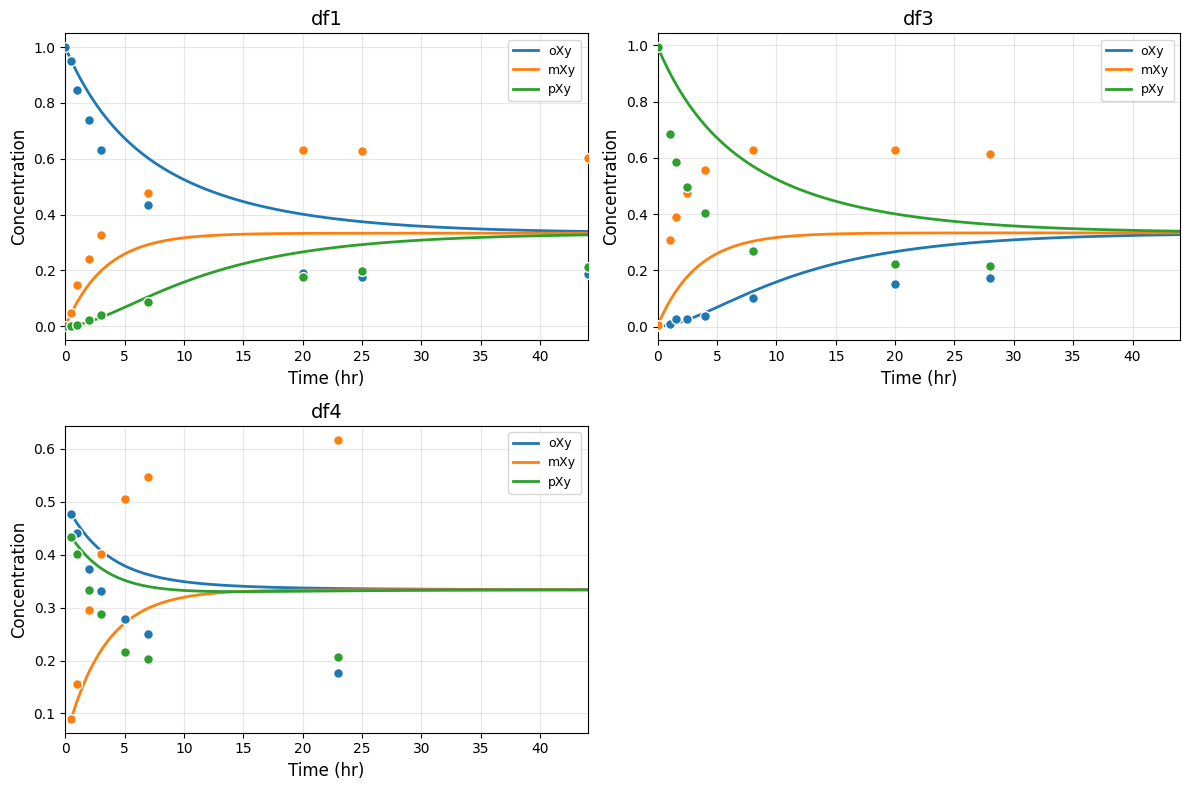


=== Concentration at the final time point ===
df1:
  oXy: 0.339460
  mXy: 0.333333
  pXy: 0.327208
df3:
  oXy: 0.326911
  mXy: 0.332999
  pXy: 0.339089
df4:
  oXy: 0.333944
  mXy: 0.333666
  pXy: 0.333389


In [9]:
# 経時変化を図示（plot_fitted_solution を使用）
fit_sci.plot_fitted_solution(
    expdata_df=[df1, df2, df3, df4], 
    plot_datasets=["df1", "df2", "df3", "df4"], 
    species=['oXy', 'mXy', 'pXy'], 
    subplot_layout=(2,2)
)